# Variant Interpretation Notebook

This notebook shows how to:

1. Create `Variant` objects.
2. Build `SequencePair` objects in different contexts.
3. Visualize variant sequence changes and annotations.
4. Load MPRA variants from a table.
5. Select LDLR variants with strongest positive and negative measured effects.
6. Predict reference/alternative expression.
7. Visualize ATAC-like model tracks and score variant effects.

In [1]:
from pathlib import Path
import os

import pandas as pd
import polars as pl
import matplotlib.pyplot as plt

from gena_expression.conditions import Condition, DescriptionLookup
from gena_expression.contexts import GenomeContext, PlasmidContext
from gena_expression.genome import Genome, GenomeRegion
from gena_expression.models import SequenceModel, VariantInterpreter
from gena_expression.scorers import (
    ExpressionDeltaScorer,
    TrackWindowScorer,
    TrackFeatureScorer,
)
from gena_expression.sequences import AnnotatedSequence, Feature, SequencePair
from gena_expression.variants import Variant

from gena_expression.plasmids import PlasmidRecord, infer_table18_primer_tails
from gena_expression.CONST import table18_primers, locations

In [2]:
API_ROOT = Path("/workspace-SR003.nfs2/estsoi/API/GENA_LM/downstream_tasks/expression_prediction/api")
DATA_DIR = API_ROOT / "data"

MPRA_TABLE = DATA_DIR / "mpra_cagi5" / "Kircher_GRCh38_ALL.tsv"
DESCRIPTION_DIR = DATA_DIR / "atacseq_generated_descriptions"
PLASMID_DIR = DATA_DIR / "plasmids"

GENOME_FASTA = Path("/home/jovyan/.cache/mpramnist/data/Kircher/hg38.fa")
GENOME_ANNOTATION = Path(
    "/workspace-SR003.nfs2/estsoi/scRNA_seq_experiments/GENA_LM/"
    "downstream_tasks/expression_prediction/datasets/data/genomes/hg38/"
    "gencode.v29.primary_assembly.annotation_UCSC_names.gtf"
)

DEVICE = "cuda:5"
os.environ["GENALM_HOME"] = Path('../../../../..').resolve().__str__()

## Load Genome and Conditions

`Genome` reads sequence from FASTA and, if provided, annotations from GTF.

`DescriptionLookup` selects metadata records that become model conditions.

In [3]:
genome = Genome(
    fasta_path=GENOME_FASTA,
    annotation=GENOME_ANNOTATION,
)

In [4]:
lookup = DescriptionLookup(
    json_dir=DESCRIPTION_DIR,
    keys=["K562", "HepG2", "H1", 'HaCaT'],
    #K562={"id": "ENCFF578UUD"},
    #HepG2={"id": "ENCFF588KDY"},
    #H1={"id": "ENCFF081FQX"},
)

conditions = {
    name: Condition(name=name, description=lookup[name])
    for name in lookup.keys()
}

## Contexts Available

A context is a rule for turning one `Variant` into a reference/alternative `SequencePair`.

Available options:

- `variant.to_sequence_pair(genome=genome, window_bp=...)`  
  Fastest option. Fetches a simple variant-centered genomic window.

- `GenomeContext(length=..., center="variant")`  
  Reusable version of the same idea. Useful when scoring many variants with the same context settings.

- `variant.to_sequence_pair(..., primer_pairs=..., primer_locations=...)`  
  Builds the primer-defined MPRA fragment. Useful for MPRA tables where the tested sequence is defined by cloning primers.

- `PlasmidContext`  
  Low-level context for inserting fragments into an explicitly provided annotated plasmid record. This notebook does not use it because plasmid construct routing is benchmark-specific

## Create a Variant Manually and make Sequence Pair from it

Coordinates in this API are 0-based unless you pass `coordinate_system="1-based"`.

`SequencePair.ref` and `SequencePair.alt` are both `AnnotatedSequence` objects.

/workspace-SR003.nfs2/estsoi/API/GENA_LM/downstream_tasks/expression_prediction/api/src/gena_expression/variants.py:68: RuntimeWarning: Reference allele mismatch during variant validation. debug={'variant_id': 'chr19:11089231:C>T', 'chrom': 'chr19', 'pos0': 11089231, 'pos1': 11089232, 'ref': 'C', 'alt': 'T', 'ref_len': 1, 'alt_len': 1, 'observed': 'G', 'local_start': 0}
  variant.validate(genome)
/workspace-SR003.nfs2/estsoi/API/GENA_LM/downstream_tasks/expression_prediction/api/src/gena_expression/contexts.py:75: RuntimeWarning: Reference allele mismatch in annotated sequence context; continuing with requested ref/alt replacement. debug={'variant_id': 'chr19:11089231:C>T', 'chrom': 'chr19', 'pos0': 11089231, 'pos1': 11089232, 'ref': 'C', 'alt': 'T', 'ref_len': 1, 'alt_len': 1, 'observed': 'G', 'sequence_name': 'LDLR_window_2kb', 'sequence_length': 2000, 'local_start': 1000, 'local_end': 1001}
  alt = variant.apply_to(ref, offset=local_variant_start)


2000 2000


(<Figure size 1200x280 with 1 Axes>,
 <Axes: title={'center': 'ALT genomic window'}, xlabel='Sequence coordinate'>)

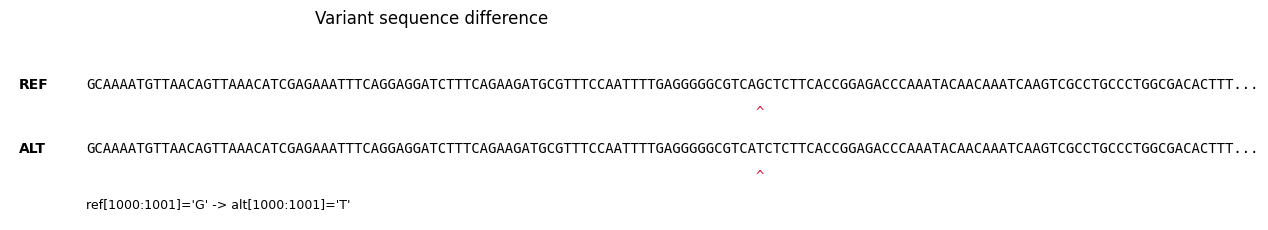

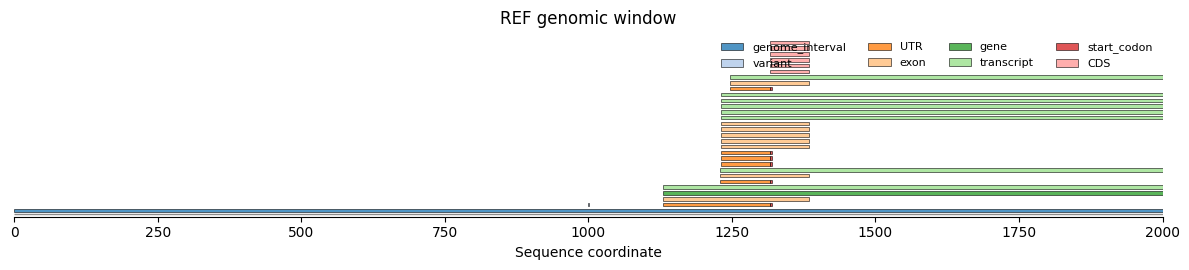

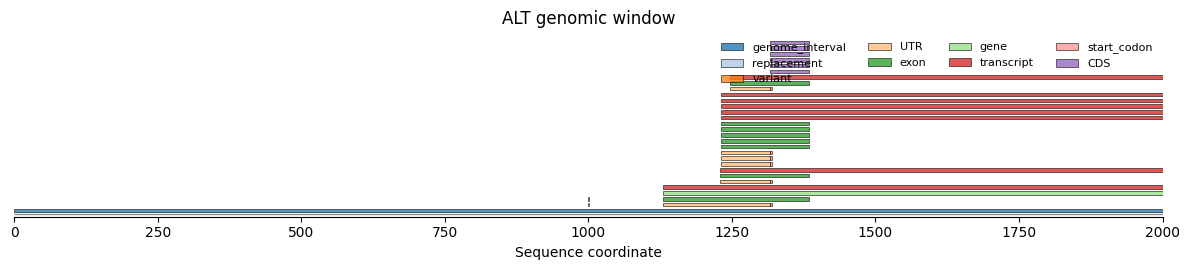

In [5]:
variant = Variant.from_str(
    "chr19:11089231:C>T",
    genome=genome,
    coordinate_system="0-based",
)
pair = variant.to_sequence_pair(
    genome=genome,
    window_bp=2_000,
    name="LDLR_window_2kb",
)

print(len(pair.ref), len(pair.alt))
pair.plot_difference(flank=80)
pair.ref.plot_annotations(label_features=False, title="REF genomic window")
pair.alt.plot_annotations(label_features=False, title="ALT genomic window")

## Use `GenomeContext` Explicitly

This is equivalent in spirit to `window_bp`, but convenient when reused for many variants.

/workspace-SR003.nfs2/estsoi/API/GENA_LM/downstream_tasks/expression_prediction/api/src/gena_expression/contexts.py:75: RuntimeWarning: Reference allele mismatch in annotated sequence context; continuing with requested ref/alt replacement. debug={'variant_id': 'chr19:11089231:C>T', 'chrom': 'chr19', 'pos0': 11089231, 'pos1': 11089232, 'ref': 'C', 'alt': 'T', 'ref_len': 1, 'alt_len': 1, 'observed': 'G', 'sequence_name': 'LDLR_from_GenomeContext', 'sequence_length': 10000, 'local_start': 5000, 'local_end': 5001}
  alt = variant.apply_to(ref, offset=local_variant_start)


(<Figure size 1200x240 with 1 Axes>,
 <Axes: title={'center': 'Variant sequence difference'}>)

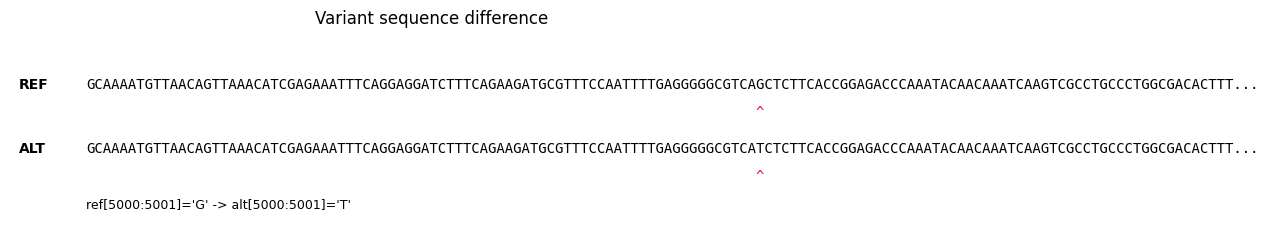

In [6]:
genomic_context = GenomeContext(
    length=10_000,
    center="variant",
    strand="+",
    include_features=True,
)

pair_from_context = genomic_context.build(
    variant,
    genome=genome,
    name="LDLR_from_GenomeContext",
)

pair_from_context.plot_difference(flank=80)

## Primer-Defined MPRA Fragment

For MPRA variants, the tested fragment may be better represented by primers than by an arbitrary fixed window.

Here `primer_pair_name="LDLR"` restricts matching to the LDLR primers.

318 318


/workspace-SR003.nfs2/estsoi/API/GENA_LM/downstream_tasks/expression_prediction/api/src/gena_expression/variants.py:188: RuntimeWarning: Reference allele mismatch in primer search window; continuing with requested ref/alt replacement. debug={'variant_id': 'chr19:11089231:C>T', 'chrom': 'chr19', 'pos0': 11089231, 'pos1': 11089232, 'ref': 'C', 'alt': 'T', 'ref_len': 1, 'alt_len': 1, 'observed': 'G', 'search_start': 11089130, 'local_start': 101, 'search_length': 518, 'forced_bounds': (100, 418)}
  return self._to_primer_sequence_pair(


(<Figure size 1200x280 with 1 Axes>,
 <Axes: title={'center': 'LDLR MPRA fragment REF'}, xlabel='Sequence coordinate'>)

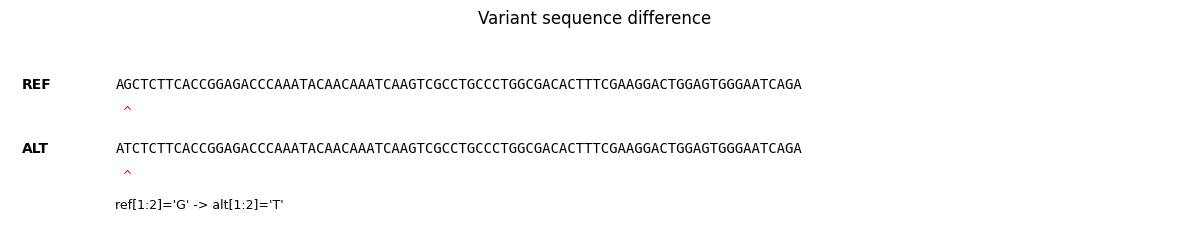

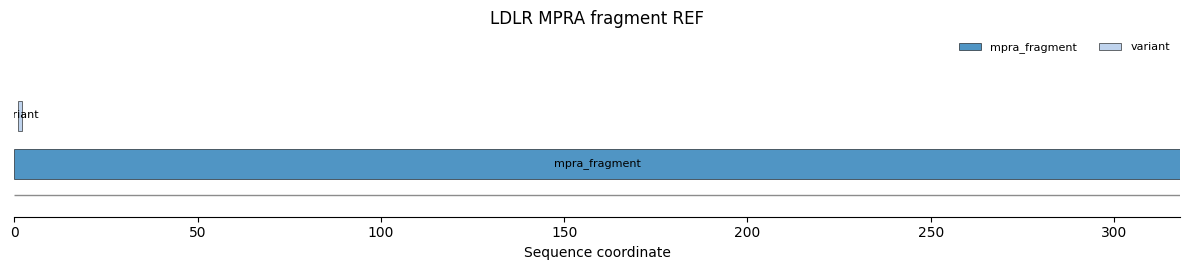

In [7]:
mpra_pair = variant.to_sequence_pair(
    genome=genome,
    primer_pairs=table18_primers,
    primer_locations=locations,
    primer_pair_name="LDLR",
    primer_min_match=15,
    include_primer_tails=False,
    name="LDLR_mpra_fragment"
)

print(len(mpra_pair.ref), len(mpra_pair.alt))
mpra_pair.plot_difference(flank=80)
mpra_pair.ref.plot_annotations(label_features=True, title="LDLR MPRA fragment REF")

## Loading Additional Contexts

Sometimes a variant pair is not enough by itself. You may want to place the reference and alternative sequences into a larger biological context before prediction.

The API has two useful context styles:

- **Safe-harbor genomic context**: wraps an existing sequence or sequence pair with genomic flanks from a known safe-harbor locus.
- **Plasmid context**: inserts reference and alternative MPRA fragments into an annotated plasmid record.

The safe-harbor context is applied with `SequencePair.map(...)`.  
The plasmid context is built with `PlasmidContext.build(...)`.

### Safe-Harbor Genomic Context

`GenomeRegion.genomic_context(...)` returns a callable that accepts a sequence and pads it with genomic flanks to a fixed target length.

This is useful when you want to test the same MPRA fragment or variant sequence inside a neutral genomic locus such as `AAVS1`.

318 20000


(<Figure size 1200x280 with 1 Axes>,
 <Axes: title={'center': 'ALT sequence in AAVS1 safe-harbor context'}, xlabel='Sequence coordinate'>)

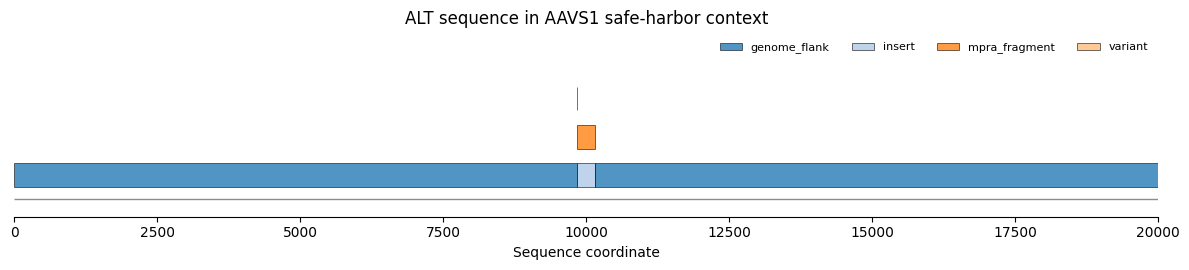

In [8]:
safe_harbor_context = GenomeRegion(
    genome_path=GENOME_FASTA,
).genomic_context(
    region="AAVS1",
    target_length=20_000,
)

safe_harbor_pair = mpra_pair.map(safe_harbor_context)

print(len(mpra_pair.ref), len(safe_harbor_pair.ref))
safe_harbor_pair.alt.plot_annotations(
    label_features=False,
    title="ALT sequence in AAVS1 safe-harbor context",
)

You can also use manual genomic coordinates instead of a named safe-harbor region.

Coordinates for `GenomeRegion.genomic_context(...)` are 1-based.

(<Figure size 1200x280 with 1 Axes>,
 <Axes: title={'center': 'ALT sequence in manual genomic context'}, xlabel='Sequence coordinate'>)

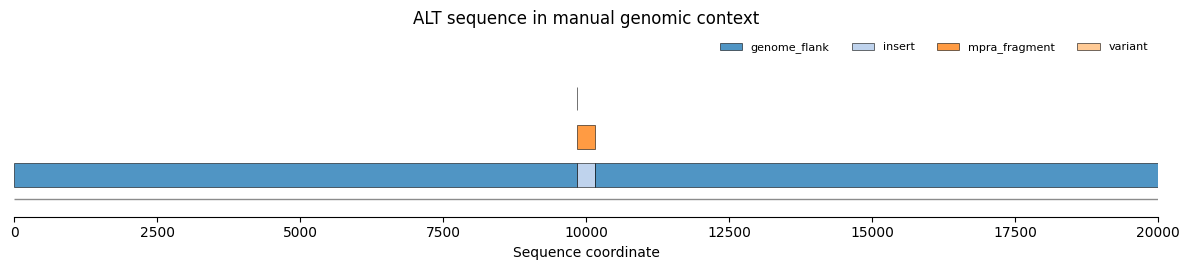

In [9]:
manual_genomic_context = GenomeRegion(
    genome_path=GENOME_FASTA,
).genomic_context(
    chromosome="19",
    position=55_112_144,
    target_length=20_000,
)

manual_context_pair = mpra_pair.map(manual_genomic_context)

manual_context_pair.alt.plot_annotations(
    label_features=False,
    title="ALT sequence in manual genomic context",
)

### Plasmid Context

`PlasmidContext` inserts reference and alternative fragments into an annotated plasmid.

Unlike safe-harbor context, `PlasmidContext` is not applied with `.map(...)`.  
Instead, create a sequence-level `Variant` from the existing reference and alternative fragments, then call `plasmid_context.build(...)`.

4870 4869


(<Figure size 1200x280 with 1 Axes>,
 <Axes: title={'center': 'ALT sequence in plasmid context'}, xlabel='Sequence coordinate'>)

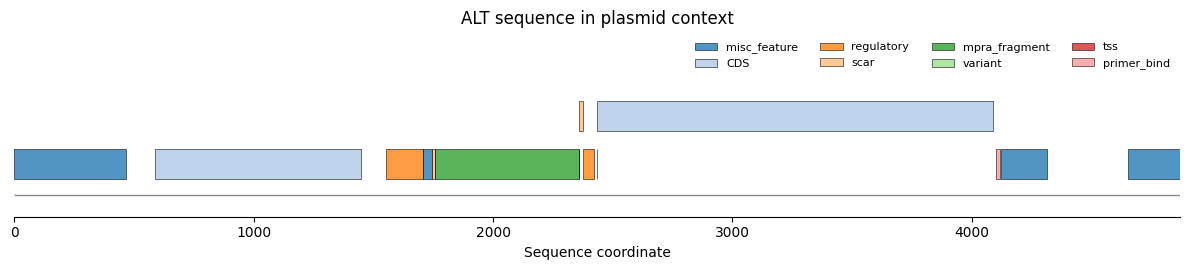

In [10]:
pair = Variant.from_str('chr1:209815789:G>').to_sequence_pair(primer_pairs=table18_primers, primer_pair_name='IRF6', genome=genome, 
                                                            primer_window_bp=2000)
PLASMID_ACCESSION = "MK484105.1"

plasmid = PlasmidRecord.from_files(
    genbank_path=PLASMID_DIR / PLASMID_ACCESSION / f"{PLASMID_ACCESSION}.gb",
    fasta_path=PLASMID_DIR / PLASMID_ACCESSION / f"{PLASMID_ACCESSION}.fa",
    reporter_feature_name="luc2",
)

primer_tails = infer_table18_primer_tails(
    GENOME_FASTA,
    table18_primers=table18_primers,
    locations=locations,
    flank=200,
    min_match=15,
)

plasmid_context = PlasmidContext(
    plasmid=plasmid,
    element="IRF6",
    primer_tails=primer_tails,
    context_size=None,
    circular=True,
    allow_repeats=False,
    variant_feature_name='variant'
)

fragment_variant = Variant.from_sequences(
    pair.ref,
    pair.alt,
    name="LDLR_fragment_variant",
)

plasmid_pair = fragment_variant.to_sequence_pair(context=plasmid_context)

print(len(plasmid_pair.ref), len(plasmid_pair.alt))
plasmid_pair.ref.plot_annotations(
    label_features=False,
    title="ALT sequence in plasmid context",
    hide_types=('source', 'insert')
)

## Load MPRA Table

The Kircher table stores `-` for empty alleles. `Variant.from_str(...)` understands `-`, so we keep it.

In [11]:
dataset = pl.read_csv(
    MPRA_TABLE,
    separator="\t",
    infer_schema_length=10_000,
)

dataset = dataset.filter(pl.col.Tags>10).with_columns(
    (
        pl.lit("chr")
        + pl.col("Chromosome").cast(pl.String)
        + pl.lit(":")
        + pl.col("Position").cast(pl.String)
        + pl.lit(":")
        + pl.col("Ref").cast(pl.String)
        + pl.lit(">")
        + pl.col("Alt").cast(pl.String)
    ).alias("variant")
)

IRF6 = dataset.filter(pl.col("Element") == "IRF6")

print(IRF6.shape)
display(IRF6.head())

(1737, 12)


Element,Cell_Type,Chromosome,Position,Ref,Alt,Tags,DNA,RNA,Value,P-Value,variant
str,str,str,i64,str,str,i64,i64,i64,f64,f64,str
"""IRF6""","""HaCaT""","""1""",209815789,"""G""","""-""",21,7726,6387,0.0,0.98301,"""chr1:209815789:G>-"""
"""IRF6""","""HaCaT""","""1""",209815789,"""G""","""A""",108,33406,33691,-0.07,0.14117,"""chr1:209815789:G>A"""
"""IRF6""","""HaCaT""","""1""",209815789,"""G""","""C""",24,2936,5794,-0.15,0.14085,"""chr1:209815789:G>C"""
"""IRF6""","""HaCaT""","""1""",209815790,"""T""","""A""",18,3663,3857,-0.19,0.10675,"""chr1:209815790:T>A"""
"""IRF6""","""HaCaT""","""1""",209815790,"""T""","""C""",59,25296,26021,0.03,0.64083,"""chr1:209815790:T>C"""


## Select IRF6 Variants With Highest and Lowest Measured Effects

`Value` is the measured MPRA effect in the table.  
We select one strongest positive and one strongest negative IRF6 variant.

In [12]:
IRF6_extremes = pl.concat(
    [
        IRF6.sort("Value", descending=True).head(1).with_columns(pl.lit("highest").alias("effect_group")),
        IRF6.sort("Value", descending=False).head(1).with_columns(pl.lit("lowest").alias("effect_group")),
    ]
)

display(IRF6_extremes)

Element,Cell_Type,Chromosome,Position,Ref,Alt,Tags,DNA,RNA,Value,P-Value,variant,effect_group
str,str,str,i64,str,str,i64,i64,i64,f64,f64,str,str
"""IRF6""","""HaCaT""","""1""",209815834,"""C""","""-""",17,1381,8879,2.78,0.0,"""chr1:209815834:C>-""","""highest"""
"""IRF6""","""HaCaT""","""1""",209816335,"""G""","""C""",27,12034,1296,-3.29,0.0,"""chr1:209816335:G>C""","""lowest"""


## Build Sequence Pairs for the Selected Variants

For MPRA-table interpretation, the primer-defined fragment is usually the most faithful context.  
For model input around the local genomic locus, use `GenomeContext`.

(<Figure size 1200x280 with 1 Axes>,
 <Axes: title={'center': 'IRF6 lowest ALT fragment'}, xlabel='Sequence coordinate'>)

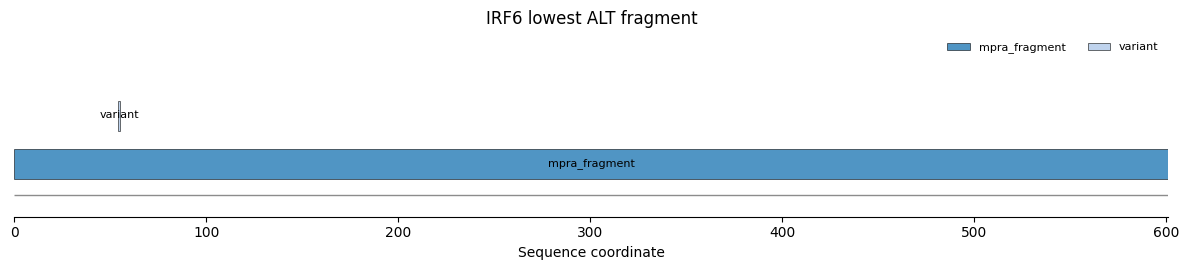

In [13]:
def row_to_variant(row) -> Variant:
    return Variant.from_str(
        row["variant"],
        genome=genome,
        coordinate_system="0-based",
    )


extreme_rows = IRF6_extremes.to_dicts()
extreme_variants = {
    row["effect_group"]: row_to_variant(row)
    for row in extreme_rows
}
pairs = {}

for row in extreme_rows:
    label = row["effect_group"]
    var = row_to_variant(row)

    pairs[label] = var.to_sequence_pair(
        genome=genome,
        primer_pairs=table18_primers,
        primer_locations=locations,
        primer_pair_name="IRF6",
        primer_min_match=15,
        include_primer_tails=False,
        name=f"IRF6_{label}_mpra_fragment",
    )

pairs['lowest'].alt.plot_annotations(label_features=True, title=f"IRF6 {label} ALT fragment")

## Load Model


In [14]:
ROOT = Path("/workspace-SR003.nfs2/estsoi/CAGI5_benchmark")
GENA_LM_ROOT = ROOT / "GENA_LM"
EXPRESSION_TASK_DIR = GENA_LM_ROOT / "downstream_tasks" / "expression_prediction"

MODEL_CLS_PATH = EXPRESSION_TASK_DIR / "expression_model_final.py"
MODEL_CLS = f"{MODEL_CLS_PATH}::ExpressionCounts"

MODEL_CHECKPOINT = ROOT / "models" / "expression_model" / "pytorch_model.bin"
MODEL_CONFIG = EXPRESSION_TASK_DIR / "inference_example_config.yaml"
DNA_TOKENIZER = GENA_LM_ROOT / "data" / "tokenizers" / "t2t_1000h_multi_32k"
DESCRIPTION_TOKENIZER = "Qwen/Qwen3-Embedding-0.6B"

model = SequenceModel.load(
    model_cls=MODEL_CLS,
    checkpoint=MODEL_CHECKPOINT,
    config=MODEL_CONFIG,
    dna_tokenizer=DNA_TOKENIZER,
    description_tokenizer=DESCRIPTION_TOKENIZER,
    dna_max_seq_len=1024,
    num_before=511,
    desc_max_seq_len=510,
    token_len_for_fetch=9,
    device=DEVICE,
)

interpreter = VariantInterpreter(model)

/home/jovyan/miniconda3/envs/api/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/workspace-SR003.nfs2/estsoi/API/GENA_LM/downstream_tasks/expression_prediction/api/src/gena_expression/models.py:140: UserWarning: 
The version_base parameter is not specified.
Please specify a compatability version level, or None.
Will assume defaults for version 1.1
  with initialize_config_dir(str(config_path.parents[0])):


Using ModernGENA from AIRI-Institute/moderngena-large


Flash Attention 2 only supports torch.float16 and torch.bfloat16 dtypes, but the current dype in ModernBertModel is torch.float32. You should run training or inference using Automatic Mixed-Precision via the `with torch.autocast(device_type='torch_device'):` decorator, or load the model with the `torch_dtype` argument. Example: `model = AutoModel.from_pretrained("openai/whisper-tiny", attn_implementation="flash_attention_2", torch_dtype=torch.float16)`


missing: 0 []
unexpected: 3 ['decoder.bias', 'head.dense.weight', 'head.norm.weight']
mismatched: []
bert dropouts: {'attention_dropout': 0.1, 'embedding_dropout': 0.1, 'mlp_dropout': 0.1}
qwen dropouts: {'attention_dropout': 0.1}
[desc_model] unfrozen transformer blocks: [24, 25, 26, 27] (total blocks=28)
[desc_model] backbone.norm trainable: True (trainable params=1,024)
[desc_model] trainable params: 62,924,800 / 595,776,512
[desc_model] trainable tensors: 45
  - layers.24.self_attn.q_proj.weight
  - layers.24.self_attn.k_proj.weight
  - layers.24.self_attn.v_proj.weight
  - layers.24.self_attn.o_proj.weight
  - layers.24.self_attn.q_norm.weight
  - layers.24.self_attn.k_norm.weight
  - layers.24.mlp.gate_proj.weight
  - layers.24.mlp.up_proj.weight
  - layers.24.mlp.down_proj.weight
  - layers.24.input_layernorm.weight
  - layers.24.post_attention_layernorm.weight
  - layers.25.self_attn.q_proj.weight
  - layers.25.self_attn.k_proj.weight
  - layers.25.self_attn.v_proj.weight
  - l

## Predict Expression Effects

`ExpressionDeltaScorer` computes `ALT - REF` expression by default.

In [15]:
condition = conditions["HaCaT"]
expression_scorer = ExpressionDeltaScorer(sign="alt-ref")

expression_results = {}

for label, pair in pairs.items():
    
    
    fragment_variant = Variant.from_sequences(
            pair.ref,
            pair.alt,
            name="IRF6_fragment_variant",
    )
    
    plasmid_pair = plasmid_context.build(
        fragment_variant,
        name="IRF6_in_plasmid",
    )
    
    result = interpreter.score_sequence_pair(
        pair=plasmid_pair,
        condition=condition,
        center='reporter_tss',
        scorer=expression_scorer,
    )
    expression_results[label] = result

    print(label)
    print("variant:", plasmid_pair.variant.id)
    print("measured Value:", [row["Value"] for row in extreme_rows if row["effect_group"] == label][0])
    print("predicted expression delta:", result.score)
    display(result.to_frame())

Casting fp32 inputs back to torch.float16 for flash-attn compatibility.


highest
variant: IRF6_fragment_variant
measured Value: 2.78
predicted expression delta: 0.02978515625


,name,score,condition,variant_id,chrom,pos,ref,alt
0,expression_delta,0.029785,HaCaT,IRF6_fragment_variant,None,556,G,


lowest
variant: IRF6_fragment_variant
measured Value: -3.29
predicted expression delta: 9.1552734375e-05


,name,score,condition,variant_id,chrom,pos,ref,alt
0,expression_delta,0.000092,HaCaT,IRF6_fragment_variant,None,54,C,G


## Visualize ATAC / Track Effects

`TrackWindowScorer` aggregates model track values inside a sequence-coordinate window around the variant.

The summary plot shows:

1. Variant sequence difference.
2. Optional sequence annotations.
3. REF track.
4. ALT track.
5. Delta track, with positive values in green and negative values in red.

highest 19.0224609375 {'ref_sequence': 'CTCTGTTTGCTTAGCTTACCTCCACTCCATGGCTCTTGTGGCTTAAGGGGGAAACCTTTGGCCACCCACCCCCATTGCCCCATACTGCTGGCATGGAAATTCCTCTGTGACAAAAAACAGAGAGAAAAGGTCACTGGGCTGAGATGAGCTTCCTGCCTAGGCAGTGGAATCCAGGCTGCCAGGACGGGTCTGGGCCTGAACTAGAAATGCTGCCGGTTTCCCGGGCTGGGTGGGGAAGAGAGGACAAGCTGGCACTTGCCACAGCACAGAATAGTAACTGGGAGGTTGCGATGCCTGCTCTGAGCCTGAGCGAAACTCTCAGGGCCTCCAGACATTGACGCAGGTAGAGAGGTTCCCAGGCCCCAAAGCTCCAGATTCAGCCCCTGGGCTCAATCAGGGTCAAGGATAGAGCATGCTGCCTTCTTCCCACCCCCAGGACAGGCAGATGGTCACACATGTTCACATTCTGGGGTATTACTTCAGGCCTTTGGGTAAGATTAACATTCCAAAGCTCCAATCCTCAGGTTCCCCTTCATGACCTAATAGAAAGGGCATGGAGTCAGACAGATCGGGCAGAATCAACTTCCTACTCACCATTTAC', 'alt_sequence': 'CTCTGTTTGCTTAGCTTACCTCCACTCCATGGCTCTTGTGGCTTAAGGGGGAAACCTTTGGCCACCCACCCCCATTGCCCCATACTGCTGGCATGGAAATTCCTCTGTGACAAAAAACAGAGAGAAAAGGTCACTGGGCTGAGATGAGCTTCCTGCCTAGGCAGTGGAATCCAGGCTGCCAGGACGGGTCTGGGCCTGAACTAGAAATGCTGCCGGTTTCCCGGGCTGGGTGGGGAAGAGAGGACAAGCTGGCACTTGCCACAGCACAGAATAGTAACTGGGAGGTTGCGATGCCTGCTCTGAGCCTGAGCGAAACTCTCAGGGCCTCCAGACATTGAC

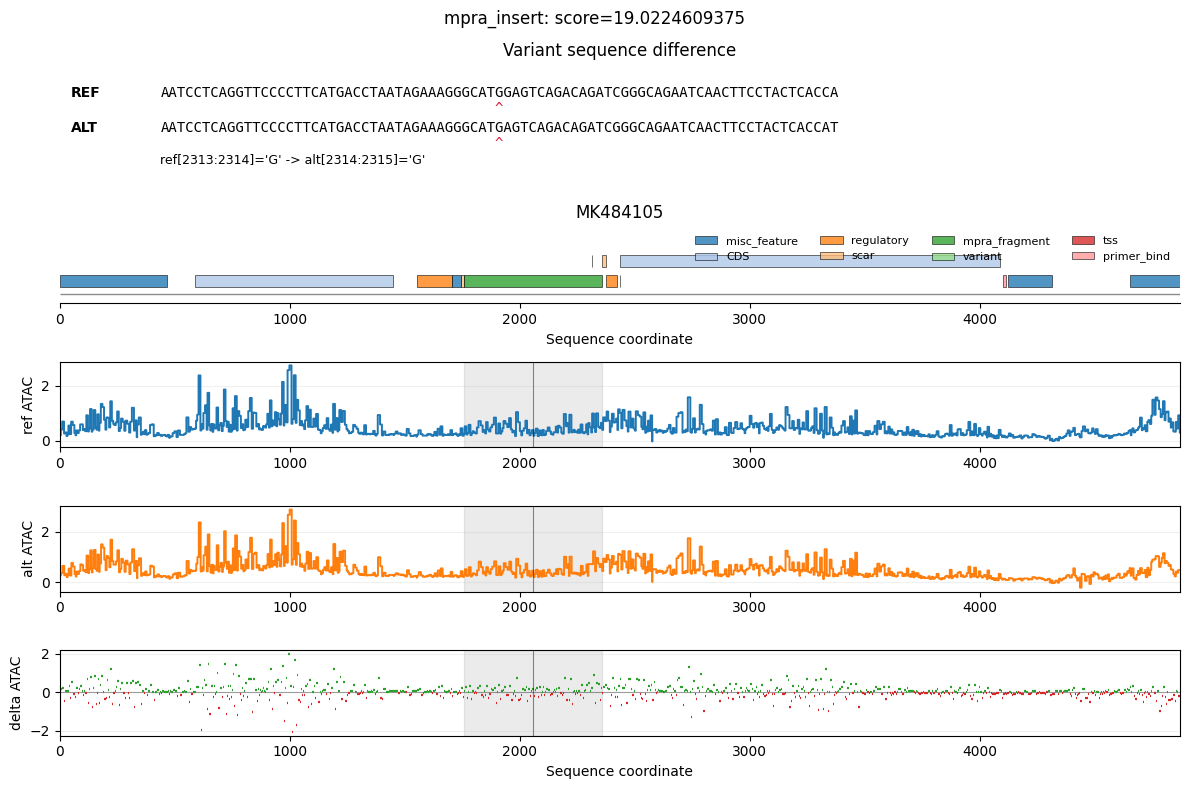

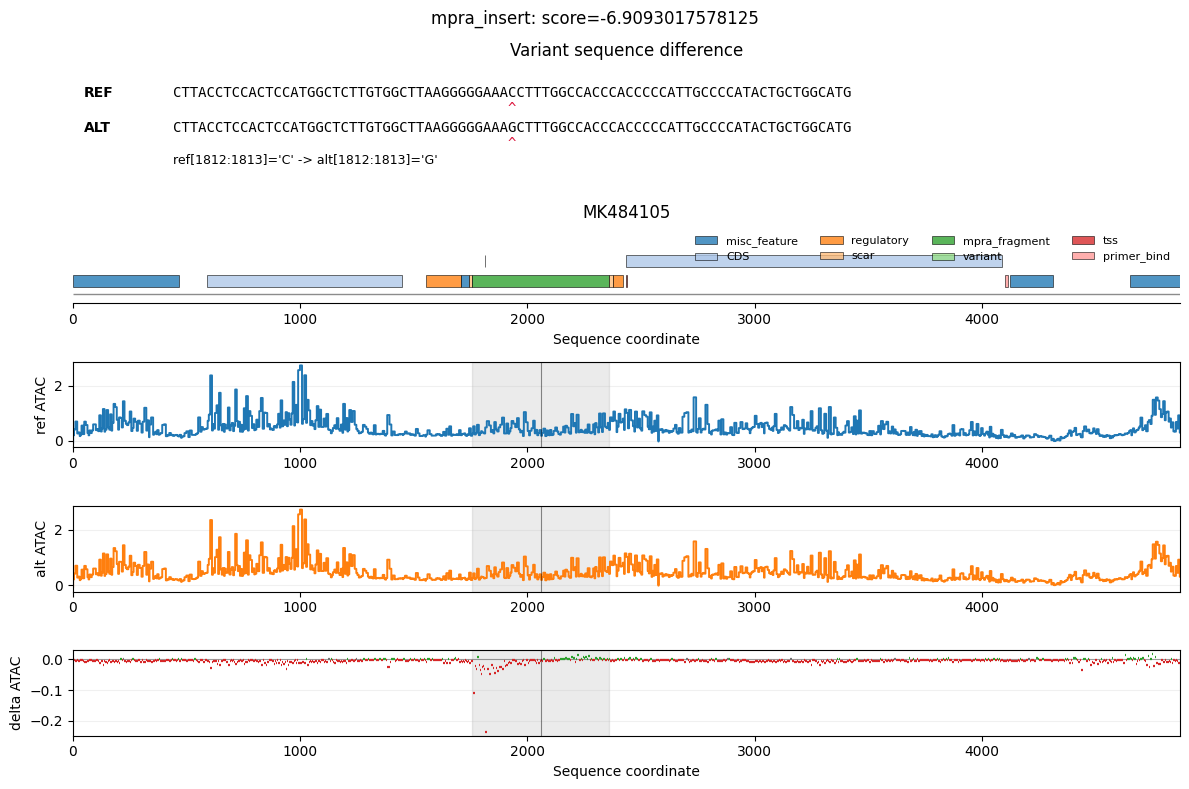

In [16]:
track_scorer = TrackWindowScorer(
    track="atac",
    center="reporter_tss",
    width_bp=4000,
    aggregate="sum",
    sign="alt-ref",
    channel=0,
    name='mpra_insert'
)
track_feature_scorer = TrackFeatureScorer(
    features=['mpra_insert'],
    track="atac",
    aggregate="sum",
    sign="alt-ref",
    channel=0,
    name='mpra_insert',
)

track_results = {}

for label, pair in pairs.items():
    
    fragment_variant = Variant.from_sequences(
            pair.ref,
            pair.alt,
            name="IRF6_fragment_variant",
    )
    
    plasmid_pair = plasmid_context.build(
        fragment_variant,
        name="IRF6_in_plasmid",
    )

    result = interpreter.score_sequence_pair(
        pair=plasmid_pair,
        condition=condition,
        center="reporter_tss",
        scorer=track_feature_scorer,
    )
    track_results[label] = result

    print(label, result.score, fragment_variant.metadata)
    result.plot_summary(
        include_annotations=True,
        annotation_which="alt",
        annotation_kwargs={"label_features": False, 'hide_types': ('source', 'insert')},
        figsize=(12, 8),
    )